In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# One binary parameter, fitted once and used at both temperatures (carbon dioxide / isopentane)

This notebook recomputes **Figure 10.3-7**: the vapor-liquid equilibrium of carbon dioxide (1)
and isopentane (2) at two temperatures, predicted by the Peng-Robinson equation of state with
the van der Waals one-fluid mixing rules, drawn twice — with the binary interaction parameter
set to **zero**, and with the single fitted value **k₁₂ = 0.121**.

This is Section 10.3's method, the **φ-φ** method: no activity coefficient model and no
reference to Raoult's law, just the same equilibrium condition the whole book uses,

$$ x_i \,\phi_i^{\rm L}(x, T, P) = y_i \,\phi_i^{\rm V}(y, T, P) $$

with both fugacity coefficients from one equation of state. It is what Sections 10.1 and 10.2
were doing all along; only the route to the fugacity has changed.

**Why this figure is the anchor of the section.** At high pressure a mixture is not a
perturbation of its pure components, and the figure shows what that costs: with $k_{12} = 0$
the equation of state predicts the wrong pressures by a wide margin, and **one** number fitted
to data brings it onto the measurements at both temperatures. That number is not a fudge
factor for one isotherm — it is fitted once and used twice, at 277.59 K and at 377.65 K.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.peng_robinson import PengRobinson
from thermo.pr_mixture import PRMixture
from thermo.vle import pxy
from thermo.charts import use_book_style
use_book_style()

PSIA, K12 = 6894.757, 0.121          # psia -> Pa, and the book's fitted parameter
F_to_K = lambda F: (F - 32.0) * 5.0 / 9.0 + 273.15

# isopentane is in pure_property.csv under its systematic name
CO2 = PengRobinson.from_database("carbon dioxide")
IC5 = PengRobinson.from_database("2-methyl butane")
for c in (CO2, IC5):
    print(f"  {c.name:18s} Tc = {c.Tc:6.2f} K   Pc = {c.Pc/1e5:5.2f} bar   omega = {c.omega:.3f}")

T1, T2 = F_to_K(40.0), F_to_K(220.1)
print(f"\nthe figure's two isotherms: {T1:.2f} K and {T2:.2f} K"
      f"   (40.0 and 220.1 F, as the paper tabulates them)")

  carbon dioxide     Tc = 304.10 K   Pc = 73.80 bar   omega = 0.239
  2-methyl butane    Tc = 460.40 K   Pc = 33.90 bar   omega = 0.227

the figure's two isotherms: 277.59 K and 377.65 K   (40.0 and 220.1 F, as the paper tabulates them)


## The measured data

G. J. Besserer and D. B. Robinson, *Equilibrium-Phase Properties of Isopentane–Carbon Dioxide
System*, **J. Chem. Eng. Data 20**(1), 93 (1975), Table I. Transcribed from the paper — not
read off the published plotted points, which are not metrological.

**The table checks itself, and the check caught a transcription error.** Besserer and
Robinson print the equilibrium constants beside the compositions, so $K_{\rm CO_2} = y/x$ and
$K_{i\rm C_5} = (1-y)/(1-x)$ test every row independently. The pure-isopentane row at 220.1 °F
came out of the scan as $x = 0.9000$; its printed $K_{i\rm C_5} = 1.0000$ says it is $0.0000$.
The check runs below rather than being described.

In [3]:
# P (psia), x, y = mole fraction CO2 in the liquid and vapor; K as printed in Table I.
BR_40F = np.array([
    [  6.1, 0.0000, 0.0000,  np.nan], [  22, 0.0187, 0.7073, 37.824],
    [   44, 0.0461, 0.8614, 18.685], [  85, 0.0961, 0.9279,  9.648],
    [  160, 0.2031, 0.9563,  4.709], [ 239, 0.3176, 0.9705,  3.056],
    [  309, 0.4458, 0.9793,  2.197], [ 382, 0.6077, 0.9809,  1.614],
    [  464, 0.8225, 0.9832,  1.195], [ 505, 0.9063, 0.9870,  1.089],
    [  541, 0.9706, 0.9959,  1.026], [ 565, 1.0000, 1.0000,  1.000]])
BR_220F = np.array([
    [  114, 0.0000, 0.0000,  np.nan], [ 147, 0.0107, 0.2115, 19.766],
    [  222, 0.0482, 0.4292,  8.905], [ 331, 0.0977, 0.5980,  6.121],
    [  437, 0.1506, 0.6656,  4.420], [ 545, 0.2015, 0.7124,  3.535],
    [  683, 0.2689, 0.7485,  2.784], [ 858, 0.3481, 0.7768,  2.232],
    [ 1025, 0.4362, 0.7850,  1.800], [1190, 0.5204, 0.7731,  1.486],
    [ 1290, 0.5929, 0.7488,  1.263]])

for lab, d in (("277.59 K", BR_40F), ("377.65 K", BR_220F)):
    P, x, y, K = d.T
    m = np.isfinite(K) & (x > 0)
    worst = np.max(np.abs(y[m] / x[m] / K[m] - 1))
    print(f"  {lab}: {len(d)} rows, worst disagreement with the printed K_CO2 = {100*worst:.2f} %")

  277.59 K: 12 rows, worst disagreement with the printed K_CO2 = 0.08 %
  377.65 K: 11 rows, worst disagreement with the printed K_CO2 = 0.03 %


## The two predictions

Everything below is the same call twice, differing only in $k_{12}$. `pxy` returns NaN wherever
the equation of state has no two-phase solution, and matplotlib draws NaN as a gap — which is
the honest picture near a mixture critical point, where the bubble and dew branches meet.

**Where the honesty has to be built in: the trivial root.** The equilibrium condition
$x_i \phi_i^{\rm L} = y_i \phi_i^{\rm V}$ is satisfied *identically* by $y = x$, $K = 1$ —
"equilibrium" between a phase and itself. It is a genuine root of the equations and a
physically empty one, and it is exactly what successive substitution finds outside the
two-phase region, because there the cubic has one real root and the liquid and vapor
fugacity coefficients become the same number. The residual $\sum K_i x_i - 1$ is then zero
at *every* pressure, so a plain Newton solver reports convergence wherever it started.

This isotherm is where that matters: 377.65 K is 73 K above the critical temperature of
carbon dioxide, so the whole upper half of the envelope is near-critical. `thermo.phi_phi`
therefore rejects any iterate whose incipient phase has collapsed onto the fixed one and
brackets the pressure instead. Without that, the high-pressure branch of this figure came
back as $P = 0$ — and, because the bad points were finite numbers rather than NaN, the
critical-point estimate below extrapolated straight through them.

In [4]:
def envelope(T, k12, n=140):
    kij = np.array([[0.0, k12], [k12, 0.0]])
    return pxy(PRMixture([CO2, IC5], kij=kij), T, n=n)

curves = {(T, k): envelope(T, k) for T in (T1, T2) for k in (0.0, K12)}
for (T, k), (x, y, P) in curves.items():
    ok = np.isfinite(P)
    print(f"  T = {T:6.2f} K, k12 = {k:.3f}:  {ok.sum():3d}/{len(P)} points converged,"
          f"  P up to {np.nanmax(P)/1e5:7.2f} bar")

  T = 277.59 K, k12 = 0.000:  140/140 points converged,  P up to   38.87 bar
  T = 277.59 K, k12 = 0.121:  140/140 points converged,  P up to   38.87 bar
  T = 377.65 K, k12 = 0.000:  101/140 points converged,  P up to   88.81 bar
  T = 377.65 K, k12 = 0.121:   95/140 points converged,  P up to   93.01 bar


### What the one number changes, in numbers

The claim the figure makes by eye — $k_{12} = 0$ is badly wrong, one fitted value fixes both
isotherms — is stated below as a deviation rather than left to the reader's judgment of two
dashed curves. Each measured liquid composition is a bubble-point calculation, so the
comparison is direct: no interpolation, no reading off the plot.

In [5]:
def bubble_deviation(T, data, k12):
    """Mean |%| error in bubble pressure at each measured liquid composition."""
    m = PRMixture([CO2, IC5], kij=np.array([[0.0, k12], [k12, 0.0]]))
    err = []
    for P_psia, x1, _, _ in data:
        if x1 <= 0.0 or x1 >= 1.0:                 # the pure ends are not a test of k12
            continue
        P, _ = m.bubble_pressure([x1, 1.0 - x1], T)
        if np.isfinite(P):
            err.append(100.0 * (P / (P_psia * PSIA) - 1.0))
    return np.mean(np.abs(err)), len(err)

for T, data, lab in ((T1, BR_40F, "277.59 K"), (T2, BR_220F, "377.65 K")):
    d0, n0 = bubble_deviation(T, data, 0.0)
    d1, n1 = bubble_deviation(T, data, K12)
    print(f"  {lab}:  k12 = 0     -> {d0:5.1f} % mean error over {n0} points")
    print(f"            k12 = 0.121 -> {d1:5.1f} % mean error over {n1} points")

  277.59 K:  k12 = 0     ->  27.9 % mean error over 10 points
            k12 = 0.121 ->   2.9 % mean error over 10 points
  377.65 K:  k12 = 0     ->  18.6 % mean error over 10 points
            k12 = 0.121 ->   2.8 % mean error over 10 points


### Estimating the mixture critical point

The caption marks the **estimated mixture critical points at 377.65 K** for both $k_{12}$
values. A mixture critical point is where the bubble and dew curves meet — where the coexisting
liquid and vapor become the same phase, $x \to y$ — so it is found by following $y - x$ up the
envelope and asking where it vanishes, rather than by reading the top of a drawn curve.

It has to be an *estimate*, and the reason is structural, not an apology.
Approaching the critical point the two phases become alike, the residual $\sum K_i x_i - 1$
flattens toward the solver's own noise floor, and the pressure at which it crosses zero stops
being determined by thermodynamics. `thermo.phi_phi` refuses those points rather than
returning them, so the envelope **stops where it stops meaning something** — at $y - x$ of
about 0.015 here. Extrapolating $y - x$ to zero from the resolved part is then the honest way
to place the critical point, and the estimate is steady: it does not move whether the last
three points or the last fifteen are used.

**Which symbol is which.** The open circle is $k_{12} = 0.121$ and the open square is
$k_{12} = 0$, each sitting on its own curve. The printed caption assigns them the other way
round, which contradicts the art itself; the caption is what is wrong (erratum E19).

In [6]:
def critical_estimate(T, k12):
    x, y, P = envelope(T, k12, n=400)
    ok = np.isfinite(P) & (y > x)
    x, y, P = x[ok], y[ok], P[ok]
    tail = slice(-6, None)                       # the last few converged points
    d = (y - x)[tail]
    if len(d) < 3 or d[-1] >= d[0]:
        return x[-1], P[-1]
    xc = np.interp(0.0, d[::-1], x[tail][::-1])  # where y - x extrapolates to zero
    Pc = np.interp(0.0, d[::-1], P[tail][::-1])
    return float(xc), float(Pc)

crit = {k: critical_estimate(T2, k) for k in (0.0, K12)}
for k, (xc, Pc) in crit.items():
    print(f"  k12 = {k:.3f}:  estimated mixture critical point at 377.65 K,"
          f"  x_CO2 = {xc:.3f},  P = {Pc/1e5:6.2f} bar")
print(f"\n  the fitted parameter moves the critical pressure by "
      f"{abs(crit[0.0][1]-crit[K12][1])/1e5:.1f} bar")

  k12 = 0.000:  estimated mixture critical point at 377.65 K,  x_CO2 = 0.724,  P =  88.84 bar
  k12 = 0.121:  estimated mixture critical point at 377.65 K,  x_CO2 = 0.679,  P =  92.99 bar

  the fitted parameter moves the critical pressure by 4.1 bar


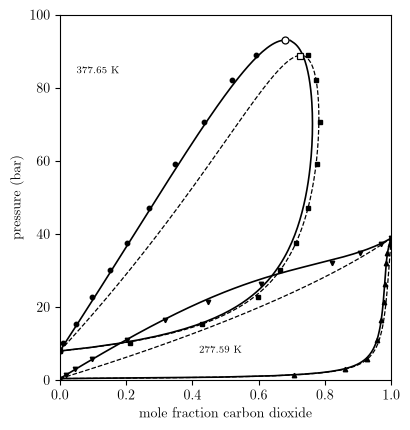

In [7]:
# MARKERS. The measured points are FILLED, per the caption: 277.59 K is v liquid /
# ^ vapor, 377.65 K is o liquid / s vapor. Filled means filled *black* --
# [[black-not-gray]] forbids tint, not ink -- and it is the fill, not the shape, that
# separates a measurement from a computed point.
#
# The two estimated mixture critical points are the OPEN circle and square, and each
# sits on ITS OWN curve: the open circle belongs to k12 = 0.121 (the solid curve, and
# the higher critical point) and the open square to k12 = 0 (the dashed one). That is
# what the ART shows. The CAPTION says the opposite, and the caption is the
# one that is wrong -- erratum E19, corrected in c10.docx and ch10.yaml.
CRIT_MARK = {0.0: "s", K12: "o"}            # k12 = 0 -> square, k12 = 0.121 -> circle

fig, ax = plt.subplots(figsize=(4.2, 4.4))
for d, mk_l, mk_v in ((BR_40F, "v", "^"), (BR_220F, "o", "s")):
    P, x, y, _ = d.T
    ax.plot(x, P * PSIA / 1e5, mk_l, color="k", ms=3.2, lw=0)
    ax.plot(y, P * PSIA / 1e5, mk_v, color="k", ms=3.2, lw=0)
for (T, k), (x, y, P) in curves.items():
    style = dict(ls="--", lw=0.9) if k == 0.0 else dict(ls="-", lw=1.2)
    ax.plot(x, P / 1e5, color="k", **style)
    ax.plot(y, P / 1e5, color="k", **style)
for k, (xc, Pc) in crit.items():
    ax.plot([xc], [Pc / 1e5], CRIT_MARK[k],
            mfc="white", mec="k", mew=0.9, ms=5.0, zorder=5)
ax.set_xlabel("mole fraction carbon dioxide")
ax.set_ylabel("pressure (bar)")
ax.set_xlim(0, 1); ax.set_ylim(0, 100)

# Each isotherm is labeled INSIDE its own two-phase envelope, in data coordinates.
# The axes-fraction placement this replaces put "277.59 K" at 28 bar and x = 0.04,
# which is on the 377.65 K bubble curve -- the label named the wrong isotherm.
ax.text(0.05, 84, "377.65 K", fontsize=7)
ax.text(0.42, 7.5, "277.59 K", fontsize=7)
fig.tight_layout()

**Read the two isotherms differently.** At 277.59 K the mixture is far below both critical
temperatures and $k_{12} = 0$ is merely inaccurate. At 377.65 K — above the critical temperature
of carbon dioxide, 304.2 K — the envelope closes at a mixture critical point, and there
$k_{12} = 0$ is not just off in pressure: it puts the critical point in the wrong place, which
is a qualitative error about where the two-phase region *ends*.

**One number, fitted once, used at both temperatures.** That is the answer to a
student who suspects binary parameters of being curve-fitting: $k_{12}$ carries no temperature
dependence here, and it corrects both isotherms at once.

## Print art

In [8]:
# --- Print art: Figure 10.3-7 ----------------------------------------------
#   pdf/Fig_10.3-7.pdf -> deliverables/figures/print-bw/ch10/c10f030.pdf
# c10f030, NOT c10f007: the .docx slugs restart per section, and the verified
# map in revision_notes/pre-submission/chapters/c10.md §1 is what production needs. Markers follow the
# caption (filled = measured, open = the estimated critical points); the two k12
# cases separate by dash, and every mark is pure black ([[black-not-gray]]).
import os
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_10.3-7.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_10.3-7.pdf")

wrote pdf/Fig_10.3-7.pdf


## Your turn

1. $k_{12} = 0.121$ was fitted to these data. Refit it yourself — minimize the deviation in
   bubble pressure over both isotherms at once — and see how sharply the optimum is defined.
   How much does the figure change if you use 0.10 or 0.14?
2. Fit $k_{12}$ to each isotherm *separately*. If the two values differ, what does that say
   about the mixing rule, and is the difference bigger or smaller than the scatter in the data?
3. The estimated critical points come from extrapolating $y - x$ to zero over the last few
   resolved points, and the answer is insensitive to how many you use. Now extend the envelope
   past where the solver stops: call `bubble_pressure` directly at $x = 0.72$ and $0.74$ with
   $k_{12} = 0.121$ and see what comes back, and why nothing useful could.
4. Carbon dioxide is supercritical at 377.65 K, so it has no vapor pressure and the envelope
   cannot reach $x = 1$. Where does the 377.65 K bubble curve actually end, and why is that not
   the critical point?
5. The 277.59 K isotherm needs none of this care — its envelope runs cleanly from one pure
   component to the other. What is different about it, and at what temperature would carbon
   dioxide/isopentane start to give the solver the same trouble?